/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Missing values in TotalCharges: 11
(7032, 46)
Training data shape: (5625, 45)
Testing data shape: (1407, 45)
Accuracy Score: 78.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/tmp/ipykernel_55/1885794516.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


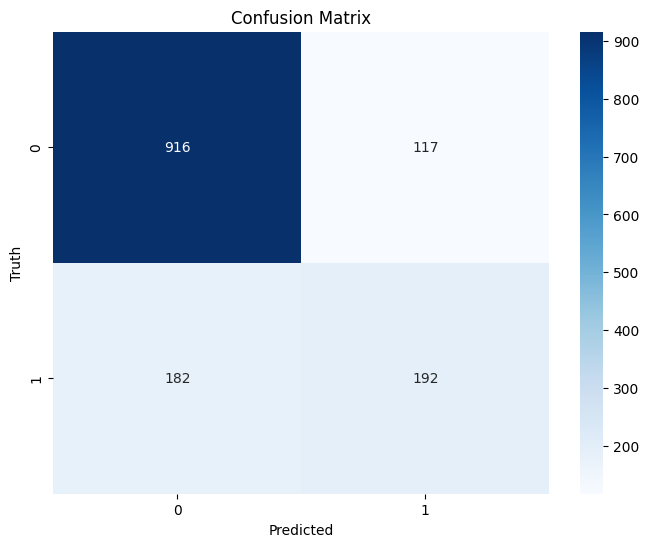

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np 
import pandas as pd 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import pandas as pd                 # Data tables
import numpy as np                  # Math operations
import matplotlib.pyplot as plt     # Plotting graphs
import seaborn as sns               # Makes graphs look nice
from sklearn.model_selection import train_test_split # Splits data
from sklearn.preprocessing import MinMaxScaler       # Scales numbers
from sklearn.linear_model import LogisticRegression  # Model used
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score #To measure success


df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

# Convert TotalCharges to numbers. Errors='coerce' turns bad data into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# Drop the rows with missing values (Only 11 rows out of 7000+)
df.dropna(inplace=True)

df.drop('customerID', axis=1, inplace=True)

# Convert Yes/No to 1/0 respectively
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

#Convert categorical columns automatically
df = pd.get_dummies(df)

print(df.shape)

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

# X is the data used to make predictions
X = df.drop('Churn', axis=1)

# y represents Churn
y = df['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()